# **Part 1: N-gram Language Model**

**Requirements:**
1. Data Preprocessing (tokenization, lowercasing, punctuation removal)
2. Unigram, Bigram, and Trigram models with Laplace smoothing
3. Perplexity evaluation on test set
4. Save model parameters to disk
5. Inference function (load model, take prompt, generate text)
"""



## **Setup and Installation**


In [ ]:
# Install required library
!pip install datasets

# Import required libraries
import numpy as np
from datasets import load_dataset
from collections import defaultdict, Counter
import pickle
import re
import math
import matplotlib.pyplot as plt


## **Load Dataset**

In [ ]:
# Load dataset as specified in lab
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

print(f"Training set: {len(dataset['train']):,} sentences")
print(f"Validation set: {len(dataset['validation']):,} sentences")
print(f"Test set: {len(dataset['test']):,} sentences")

Training set: 36,718 sentences
Validation set: 3,760 sentences
Test set: 4,358 sentences


In [ ]:
# Show statistics about empty sentences
# counts how many of the first 100 sentences are empty
empty_count = sum(1 for i in range(100) if not dataset['train'][i]['text'].strip()) #[1,1,1,0,0,1,...]
print(f"\n First 100 training sentences: {empty_count} are empty, {100-empty_count} have content")


 First 100 training sentences: 25 are empty, 75 have content


In [ ]:
def get_first_nonempty_sentence(dataset_split, max_check=50):

    # Find the first non-empty sentence in a dataset split
    # Args:dataset_split: The dataset split to check , max_check: Maximum number of sentences to check
    # Returns:The first non-empty sentence text, or empty string if none found

    for i in range(min(max_check, len(dataset_split))):
        text = dataset_split[i]['text']
        if text and text.strip():
            return text
    return ""

# Show a non-empty sample
print("\nSample text from training set:")
sample_text = get_first_nonempty_sentence(dataset['train'])
if sample_text:
    print(repr(sample_text[:200]))
else:
    print("No non-empty sample found in first 50 sentences")



Sample text from training set:
' = Valkyria Chronicles III = \n'


In [ ]:
print(dataset['train'][1])

{'text': ' = Valkyria Chronicles III = \n'}


## **1. Data Preprocessing**
- **Tokenize** text into words
- **Lowercasing** all text
- **Remove punctuation**

In [ ]:
def preprocess_text(text):


    # non-tokanized sentence -> tokens of that sentence + removed punctuation + apply lowecase
    # Args: text: Input text string
    # Returns: List of tokens
    # Input:
    # "I love NLP!"
    # Output:
    # ["i","love","nlp"]


    if not isinstance(text, str) or not text.strip():
        return []

    text = text.lower()
    # remove section titles
    if text.startswith("="):
        return []


    # remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    tokens = text.split()

    return tokens

def preprocess_dataset(dataset_split): # apply the previous function to all dataset sentences

    # Preprocess entire dataset split
    # Args:dataset_splitt
    # Returns: List of token lists

    tokenized = []
    empty_count = 0
    for i, item in enumerate(dataset_split):
        tokens = preprocess_text(item['text'])
        if tokens:  # Keep only non-empty sentences
            tokenized.append(tokens)
        else:
            empty_count += 1

    print(f"   Skipped {empty_count} empty sentences")
    return tokenized




In [ ]:
# Preprocess all splits
print("Preprocessing training data...")
train_tokens = preprocess_dataset(dataset['train'])
print(f"   Processed {len(train_tokens):,} non-empty sentences")

print("\nPreprocessing validation data...")
valid_tokens = preprocess_dataset(dataset['validation'])
print(f"   Processed {len(valid_tokens):,} non-empty sentences")

print("\nPreprocessing test data...")
test_tokens = preprocess_dataset(dataset['test'])
print(f"   Processed {len(test_tokens):,} non-empty sentences")

# Show preprocessing example using a non-empty sentence
print("\nPreprocessing Example:")
# Find first non-empty sentence
example_idx = 0
for i, item in enumerate(dataset['train']):
    if item['text'].strip():
        example_idx = i
        break

original = dataset['train'][example_idx]['text'][:200]
processed = preprocess_text(original)
print(f"Original: {repr(original)}")
print(f"Processed: {' '.join(processed)}")
print(f"Tokens: {processed}")

Preprocessing training data...
   Skipped 12952 empty sentences
   Processed 23,766 non-empty sentences

Preprocessing validation data...
   Skipped 1299 empty sentences
   Processed 2,461 non-empty sentences

Preprocessing test data...
   Skipped 1467 empty sentences
   Processed 2,891 non-empty sentences

Preprocessing Example:
Original: ' = Valkyria Chronicles III = \n'
Processed: valkyria chronicles iii
Tokens: ['valkyria', 'chronicles', 'iii']


## **Build Vocabulary**

Special tokens:
- `<pad>` (0): Padding for context
- `<unk>` (1): Unknown words
- `</s>`  (2): End of sentence
- `<s>`  (3): Start of sentence



build a vocabulary for the language model and convert words into numerical IDs so the model can process text mathematically.

In [ ]:
def build_vocabulary(tokenized_sentences, min_freq=3, max_vocab_size=15000):

    # Build vocabulary from training data
    # convert words into numbers
    # Vocabulary = dictionary mapping from word to number
    # Args tokenized_sentences: List of token lists , min_freq: Minimum frequency to include word so Rare words are removed
    # Returns:word2idx, idx2word dictionaries



    # counts how many times each word appears So we know how common each word is
    word_counts = Counter()
    for sentence in tokenized_sentences:
        word_counts.update(sentence)


# word_counts wxample:
# i:2
# love:2
# ai:2
# is:1
# fun:1
# coding:1

    # Create vocabulary with special tokens
    # If a word doesn't exist in vocabulary, we replace it with <UNK>
    word2idx = {
        '<pad>':0,
        '<unk>':1,
        '<s>':2,
        '</s>':3
    }

    # Add words meeting minimum frequency

    # 15000 -> huge data set that has many words appeared only once or twice.
    # Keeping all of them would:
    # make the vocabulary huge
    # make models slower
    # increase data sparsity
    # So we limit the vocabulary size.
    for word, count in word_counts.most_common(max_vocab_size):
        if count >= min_freq:
            word2idx[word] = len(word2idx)# give index for each word
        #   {
            #  '<pad>':0,
            #  '<unk>':1,
            #  '</s>':2,
            #  'i':3,
            #  'love':4,
            #  'ai':5
        #             }

    # Create reverse mapping
    idx2word = {idx: word for word, idx in word2idx.items()}

#     {
# 0:'<pad>',
# 1:'<unk>',
# 2:'</s>',
# 3:'i',
# 4:'love',
# 5:'ai'
# }

    print(f"Total unique words: {len(word_counts):,}")
    print(f"Vocabulary size: {len(word2idx):,}")
    print(f"Words kept (min_freq={min_freq}): {len(word2idx)-4:,}")

    return word2idx, idx2word

def encode_sentence(sentence_tokens, word2idx):

    encoded = [word2idx['<s>']]

    for token in sentence_tokens:
        encoded.append(word2idx.get(token, word2idx['<unk>']))

    encoded.append(word2idx['</s>'])

    return encoded



def decode_sentence(sentence_indices, idx2word):
    """Convert indices back to tokens."""
    # numbers → words # [3,4,1] -> ['i','love','<unk>']
    return [idx2word.get(idx, '<unk>') for idx in sentence_indices]



## **2. Constructing the N-gram Model with Laplace Smoothing**

Implements:
- Unigram (n=1)
- Bigram (n=2)
- Trigram (n=3)

All with Laplace smoothing to handle unseen n-grams.



In [ ]:
class NGramModel:
    def __init__(self, n, vocab_size, smoothing=1):
        """
        Args:
            n: n-gram size (1, 2, or 3)
            vocab_size: size of vocabulary
            smoothing: Laplace smoothing parameter
        """
        self.n = n
        self.vocab_size = vocab_size
        self.smoothing = smoothing
        self.name = {1: "Unigram", 2: "Bigram", 3: "Trigram"}.get(n, f"{n}-gram")

        # Counters for calculating probabilities
        self.ngram_counts = defaultdict(int)
        self.context_counts = defaultdict(int)
        self.total_train_tokens = 0  # Optimized for Unigram

    def get_ngrams(self, sentence_indices):

        ngrams = []

        if self.n == 1:
            # skip predicting <s>
            sentence_indices = sentence_indices[1:]

        for i in range(len(sentence_indices) - self.n + 1):
            ngram = tuple(sentence_indices[i:i+self.n])
            ngrams.append(ngram)

        return ngrams

    def train(self, encoded_sentences):
        """Train model by counting n-grams."""
        total = 0
        for sentence in encoded_sentences:
            ngrams = self.get_ngrams(sentence)
            for ngram in ngrams:
                self.ngram_counts[ngram] += 1
                context = ngram[:-1]
                self.context_counts[context] += 1
                total += 1

        self.total_train_tokens = total
        print(f"{self.name}: Trained on {total:,} {self.name.lower()}s")
        print(f"         Unique {self.name.lower()}s: {len(self.ngram_counts):,}")

    def get_probability(self, ngram):
        """Calculate Laplace-smoothed probability."""
        context = ngram[:-1]
        ngram_count = self.ngram_counts.get(ngram, 0)

        if self.n == 1:
            # P(w) = (C(w) + alpha) / (N + alpha * V)
            prob = (ngram_count + self.smoothing) / (self.total_train_tokens + self.smoothing * self.vocab_size)
        else:
            # P(wn | context) = (C(context, wn) + alpha) / (C(context) + alpha * V)
            context_count = self.context_counts.get(context, 0)
            prob = (ngram_count + self.smoothing) / (context_count + self.smoothing * self.vocab_size)

        return prob

    def sentence_log_probability(self, sentence_indices):
        """Calculate log probability to prevent numerical underflow."""
        log_prob = 0.0
        ngrams = self.get_ngrams(sentence_indices)

        for ngram in ngrams:
            prob = self.get_probability(ngram)
            log_prob += math.log(max(prob, 1e-100))

        return log_prob

    def perplexity(self, encoded_sentences):
        """Calculate perplexity with debug prints for the first 2 sentences."""
        total_log_prob = 0.0
        total_ngrams = 0

        for i, sentence in enumerate(encoded_sentences):
            ngrams = self.get_ngrams(sentence)

            for ngram in ngrams:
                prob = self.get_probability(ngram)
                total_log_prob += math.log(max(prob, 1e-100))
                total_ngrams += 1

        if total_ngrams == 0: return float('inf')

        avg_log_prob = total_log_prob / total_ngrams
        return math.exp(-avg_log_prob)

    def generate_next_token(self, context):
        """Predict the next word based on context."""
        if len(context) < self.n - 1:
            context = [word2idx['<s>']] * (self.n - 1 - len(context)) + context
        else:
            context = context[-(self.n - 1):]

        context_tuple = tuple(context)
        probs = []
        for word_idx in range(self.vocab_size):
            ngram = context_tuple + (word_idx,)
            probs.append(self.get_probability(ngram))

        probs = np.array(probs)
        probs /= probs.sum()
        return np.random.choice(self.vocab_size, p=probs)

    def generate_text(self, prompt_indices, max_length=20):
        """Generate a sequence of text."""
        generated = prompt_indices.copy()
        for _ in range(max_length):
            next_token = self.generate_next_token(generated)
            generated.append(next_token)
            if next_token == word2idx.get('</s>', 3):
                break
        return generated

print("NGramModel class defined successfully.")


NGramModel class defined successfully.


In [ ]:
def get_interpolated_prob(trigram_model, bigram_model, unigram_model, trigram, lambdas=[0.7, 0.2, 0.1]):
    # trigram is a tuple like (w1, w2, w3)
    p3 = trigram_model.get_probability(trigram)    # Trigram score
    p2 = bigram_model.get_probability(trigram[1:]) # Bigram score (w2, w3)
    p1 = unigram_model.get_probability(trigram[2:]) # Unigram score (w3)

    return lambdas[0]*p3 + lambdas[1]*p2 + lambdas[2]*p1

## **Train Unigram, Bigram, and Trigram Models**

In [ ]:
vocab_sizes = [8000, 12000, 15000, 20000, 25000, 30000]

best_ppl = float('inf')
best_vocab = None

# use small validation subset for speed
valid_subset = valid_tokens[:200]

for vocab_size_candidate in vocab_sizes:

    print(f"\nTesting Vocabulary Size: {vocab_size_candidate}")

    # build vocab with candidate size
    word2idx, idx2word = build_vocabulary(
        train_tokens,
        min_freq=3,
        max_vocab_size=vocab_size_candidate
    )

    # encode sentences
    train_encoded = [encode_sentence(sent, word2idx) for sent in train_tokens]
    valid_encoded = [encode_sentence(sent, word2idx) for sent in valid_subset]

    vocab_size_current = len(word2idx)

    # build trigram model with Laplace smoothing (alpha=1)
    trigram_model = NGramModel(
        n=3,
        vocab_size=vocab_size_current
    )

    # train
    trigram_model.train(train_encoded)

    # evaluate
    ppl = trigram_model.perplexity(valid_encoded)

    print(f"   Validation Perplexity = {ppl:.2f}")

    if ppl < best_ppl:
        best_ppl = ppl
        best_vocab = vocab_size_candidate

print("\n==============================")
print("BEST PARAMETERS FOUND")
print(f"Best vocab size: {best_vocab}")
print(f"Best validation perplexity: {best_ppl:.2f}")
print("==============================")


Testing Vocabulary Size: 8000
Total unique words: 65,867
Vocabulary size: 8,004
Words kept (min_freq=3): 8,000
Trigram: Trained on 1,750,956 trigrams
         Unique trigrams: 1,112,810
   Validation Perplexity = 2904.07

Testing Vocabulary Size: 12000
Total unique words: 65,867
Vocabulary size: 12,004
Words kept (min_freq=3): 12,000
Trigram: Trained on 1,750,956 trigrams
         Unique trigrams: 1,205,511
   Validation Perplexity = 5109.50

Testing Vocabulary Size: 15000
Total unique words: 65,867
Vocabulary size: 15,004
Words kept (min_freq=3): 15,000
Trigram: Trained on 1,750,956 trigrams
         Unique trigrams: 1,245,016
   Validation Perplexity = 7158.03

Testing Vocabulary Size: 20000
Total unique words: 65,867
Vocabulary size: 20,004
Words kept (min_freq=3): 20,000
Trigram: Trained on 1,750,956 trigrams
         Unique trigrams: 1,284,956
   Validation Perplexity = 10100.59

Testing Vocabulary Size: 25000
Total unique words: 65,867
Vocabulary size: 25,004
Words kept (min_fre

In [ ]:


word2idx, idx2word = build_vocabulary(
    train_tokens,
    min_freq=3,
    max_vocab_size=best_vocab
)

train_encoded = [encode_sentence(sent, word2idx) for sent in train_tokens]
valid_encoded = [encode_sentence(sent, word2idx) for sent in valid_tokens]
test_encoded = [encode_sentence(sent, word2idx) for sent in test_tokens]

vocab_size = len(word2idx)

# print(f"Final vocabulary size: {vocab_size}")

# unigram = NGramModel(n=1, vocab_size=vocab_size, smoothing=1.0)
# unigram.train(train_encoded)

# bigram = NGramModel(n=2, vocab_size=vocab_size, smoothing=1.0)
# bigram.train(train_encoded)

# trigram = NGramModel(n=3, vocab_size=vocab_size, smoothing=1.0)
# trigram.train(train_encoded)

# models = {
#     'Unigram': unigram,
#     'Bigram': bigram,
#     'Trigram': trigram
# }



Total unique words: 65,867
Vocabulary size: 8,004
Words kept (min_freq=3): 8,000


In [ ]:
vocab_size = len(word2idx)
print(f"Vocabulary size: {vocab_size:,}")

unigram = NGramModel(n=1, vocab_size=vocab_size, smoothing=0.1)
unigram.train(train_encoded)

bigram = NGramModel(n=2, vocab_size=vocab_size, smoothing=0.1)
bigram.train(train_encoded)

trigram = NGramModel(n=3, vocab_size=vocab_size, smoothing=0.1)
trigram.train(train_encoded)

models = {
    'Unigram': unigram,
    'Bigram': bigram,
    'Trigram': trigram
}
print("\nAll models trained successfully")


Vocabulary size: 8,004
Unigram: Trained on 1,774,722 unigrams
         Unique unigrams: 8,002
Bigram: Trained on 1,774,722 bigrams
         Unique bigrams: 427,210
Trigram: Trained on 1,750,956 trigrams
         Unique trigrams: 1,112,810

All models trained successfully


#**Hyperparameters 'lambda' tuning on validation set**

In [ ]:

valid_subset = valid_encoded[:200]  # Use validation data, NOT test data
candidate_lambdas = [
    [0.7, 0.2, 0.1],
    [0.5, 0.3, 0.2],
    [0.4, 0.4, 0.2],
    [0.3, 0.5, 0.2],
    [0.1, 0.1, 0.8]  # Mostly unigram
]

best_ppl = float('inf')
best_lambdas = None

print("Tuning Lambdas on Validation Set...")

for lambdas in candidate_lambdas:
    total_log_prob = 0.0
    total_ngrams = 0

    for sentence in valid_subset:
        ngrams = trigram.get_ngrams(sentence)
        for tg in ngrams:
            prob = get_interpolated_prob(trigram, bigram, unigram, tg, lambdas)
            total_log_prob += math.log(max(prob, 1e-100))
            total_ngrams += 1

    current_ppl = math.exp(-(total_log_prob / total_ngrams))
    print(f"Lambdas {lambdas} -> Validation Perplexity: {current_ppl:.2f}")

    if current_ppl < best_ppl:
        best_ppl = current_ppl
        best_lambdas = lambdas

print(f"\nWINNER: Best Lambdas are {best_lambdas} with PPL {best_ppl:.2f}")

Tuning Lambdas on Validation Set...
Lambdas [0.7, 0.2, 0.1] -> Validation Perplexity: 463.65
Lambdas [0.5, 0.3, 0.2] -> Validation Perplexity: 378.90
Lambdas [0.4, 0.4, 0.2] -> Validation Perplexity: 352.75
Lambdas [0.3, 0.5, 0.2] -> Validation Perplexity: 333.75
Lambdas [0.1, 0.1, 0.8] -> Validation Perplexity: 397.25

WINNER: Best Lambdas are [0.3, 0.5, 0.2] with PPL 333.75


## **3. Evaluation: Perplexity**





In [ ]:
# --- CELL: FINAL TEST EVALUATION ---
# Use the winner from the validation step
final_lambdas = best_lambdas
test_subset = test_encoded[:200]

total_log_prob = 0.0
total_ngrams = 0

print(f"Applying Winner Lambdas {final_lambdas} to the Test Set...")

for sentence in test_subset:
    ngrams = trigram.get_ngrams(sentence)
    for tg in ngrams:
        prob = get_interpolated_prob(trigram, bigram, unigram, tg, final_lambdas)
        total_log_prob += math.log(max(prob, 1e-100))
        total_ngrams += 1

final_test_ppl = math.exp(-(total_log_prob / total_ngrams))

print("\n" + "="*40)
print(f"FINAL TEST SET RESULTS")
print(f"Lambdas Used (Fixed from Validation): {final_lambdas}")
print(f"Final Interpolated Test Perplexity:   {final_test_ppl:.2f}")
print("="*40)

Applying Winner Lambdas [0.3, 0.5, 0.2] to the Test Set...

FINAL TEST SET RESULTS
Lambdas Used (Fixed from Validation): [0.3, 0.5, 0.2]
Final Interpolated Test Perplexity:   325.52


Evaluating on 2891 test sentences

Calculating Unigram perplexity...
Unigram Perplexity: 480.97

Calculating Bigram perplexity...
Bigram Perplexity: 309.32

Calculating Trigram perplexity...
Trigram Perplexity: 1411.50

PERPLEXITY RESULTS
Model      | Perplexity  
------------------------------
Unigram    |       480.97
Bigram     |       309.32
Trigram    |      1411.50


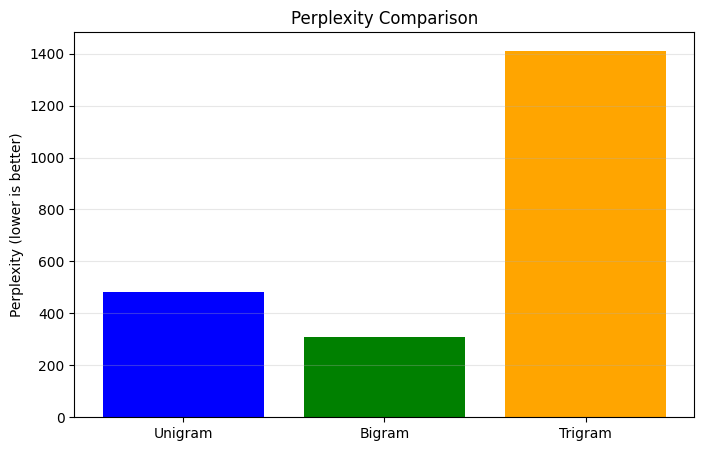


 Lower perplexity = better model


In [ ]:

# Use subset of test data for evaluation
test_subset = test_encoded[:]  # First 200 test sentences
print(f"Evaluating on {len(test_subset)} test sentences")

# Calculate perplexity for each model
perplexities = {}

for name, model in models.items():
    print(f"\nCalculating {name} perplexity...")
    ppl = model.perplexity(test_subset)
    perplexities[name] = ppl
    print(f"{name} Perplexity: {ppl:.2f}")

# Display results
print("\nPERPLEXITY RESULTS")
print(f"{'Model':10} | {'Perplexity':12}")
print("-"*30)
for name, ppl in perplexities.items():
    print(f"{name:10} | {ppl:12.2f}")

# Plot comparison
plt.figure(figsize=(8, 5))
plt.bar(perplexities.keys(), perplexities.values(), color=['blue', 'green', 'orange'])
plt.title('Perplexity Comparison')
plt.ylabel('Perplexity (lower is better)')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n Lower perplexity = better model")


## **4. Saving and Inference**



#### Save model parameters for later use.

In [ ]:
def save_model(model, word2idx, idx2word, filename):

    # Save model and vocabulary to disk.

    model_data = {
        'n': model.n,
        'vocab_size': model.vocab_size,
        'smoothing': model.smoothing,
        'ngram_counts': dict(model.ngram_counts),
        'context_counts': dict(model.context_counts),
        'word2idx': word2idx,
        'idx2word': idx2word
    }

    with open(filename, 'wb') as f:
        pickle.dump(model_data, f)

    print(f" Saved to {filename}")

def load_model(filename):

    # Load model from disk.

    with open(filename, 'rb') as f:
        model_data = pickle.load(f)

    # Recreate model
    model = NGramModel(
        n=model_data['n'],
        vocab_size=model_data['vocab_size'],
        smoothing=model_data['smoothing']
    )

    # Restore counts
    model.ngram_counts = defaultdict(int, model_data['ngram_counts'])
    model.context_counts = defaultdict(int, model_data['context_counts'])

    print(f" Loaded from {filename}")
    return model, model_data['word2idx'], model_data['idx2word']

# Save all models
print("\nSaving models...")
save_model(unigram, word2idx, idx2word, 'unigram_model.pkl')
save_model(bigram, word2idx, idx2word, 'bigram_model.pkl')
save_model(trigram, word2idx, idx2word, 'trigram_model.pkl')
print("\nAll models saved")


Saving models...
 Saved to unigram_model.pkl
 Saved to bigram_model.pkl
 Saved to trigram_model.pkl

All models saved


### **Inference Function**
1. Load saved model from disk
2. Take input text prompt
3. Generate next tokens until </s> or max length

In [ ]:
# ===============================
# Saving and Loading N-gram Models
# ===============================

def save_model(model, word2idx, idx2word, filename):
    """
    Save model parameters and vocabulary to disk.
    """

    model_data = {
        'n': model.n,
        'vocab_size': model.vocab_size,
        'smoothing': model.smoothing,
        'ngram_counts': dict(model.ngram_counts),
        'context_counts': dict(model.context_counts),
        'word2idx': word2idx,
        'idx2word': idx2word
    }

    with open(filename, 'wb') as f:
        pickle.dump(model_data, f)

    print(f" Saved to {filename}")


def load_model(filename):
    """
    Load saved model from disk.
    """

    with open(filename, 'rb') as f:
        model_data = pickle.load(f)

    # Recreate model object
    model = NGramModel(
        n=model_data['n'],
        vocab_size=model_data['vocab_size'],
        smoothing=model_data['smoothing']
    )

    # Restore counts
    model.ngram_counts = defaultdict(int, model_data['ngram_counts'])
    model.context_counts = defaultdict(int, model_data['context_counts'])

    # Restore token count (needed for unigram probability)
    model.total_train_tokens = sum(model.ngram_counts.values())

    print(f" Loaded from {filename}")

    return model, model_data['word2idx'], model_data['idx2word']

In [ ]:
# ===============================
# Save All Trained Models
# ===============================

print("\nSaving models...")

save_model(unigram, word2idx, idx2word, 'unigram_model.pkl')
save_model(bigram, word2idx, idx2word, 'bigram_model.pkl')
save_model(trigram, word2idx, idx2word, 'trigram_model.pkl')

print("\nAll models saved successfully.")


Saving models...
 Saved to unigram_model.pkl
 Saved to bigram_model.pkl
 Saved to trigram_model.pkl

All models saved successfully.


In [ ]:
# ===============================
# Inference: Text Generation
# ===============================

def generate_with_model(model_file, prompt, max_tokens=20):
    """
    Load model from disk and generate text from a prompt.
    """

    # Load model
    model, word2idx, idx2word = load_model(model_file)

    # Preprocess prompt
    tokens = preprocess_text(prompt)

    # Convert tokens to indices
    encoded_prompt = [word2idx.get(w, word2idx['<unk>']) for w in tokens]

    # Add start token
    encoded_prompt = [word2idx['<s>']] + encoded_prompt

    generated = encoded_prompt.copy()

    # Generate tokens sequentially
    for _ in range(max_tokens):

        next_token = model.generate_next_token(generated)

        generated.append(next_token)

        # Stop if end token generated
        if next_token == word2idx['</s>']:
            break

    # Convert indices back to words
    words = [idx2word.get(i, '<unk>') for i in generated]

    sentence = " ".join(words)

    print(sentence)

    return sentence

In [ ]:
# ===============================
# Test Inference
# ===============================

test_prompt = "the city of"
print(f"\nTest prompt: '{test_prompt}'")

models_to_test = [
    ('unigram_model.pkl', 'Unigram'),
    ('bigram_model.pkl', 'Bigram'),
    ('trigram_model.pkl', 'Trigram')
]

for model_file, model_name in models_to_test:
    print(f"\n{model_name} Generation:")
    generate_with_model(model_file, test_prompt, max_tokens=12)


Test prompt: 'the city of'

Unigram Generation:
 Loaded from unigram_model.pkl
<s> the city of cancelled games intervention daydream revolution obstacles born dies kōsaku article worked diagnosed

Bigram Generation:
 Loaded from bigram_model.pkl
<s> the city of the only developed about 10 seasons her at the other <unk> <unk>

Trigram Generation:
 Loaded from trigram_model.pkl
<s> the city of archipelago eldest carlisle corbet remember susquehanna combination reviewing victory pulaski gwen hydrogen


In [ ]:
# ===============================
# Results Table
# ===============================

print("\nPerplexity Results:")
print(f"{'Model':10} | {'Perplexity':12} | {'N-grams':12}")
print("-"*40)

for name in ['Unigram', 'Bigram', 'Trigram']:
    model = models[name]
    ppl = perplexities[name]

    print(f"{name:10} | {ppl:12.2f} | {len(model.ngram_counts):12,}")


Perplexity Results:
Model      | Perplexity   | N-grams     
----------------------------------------
Unigram    |       480.95 |        8,002
Bigram     |       302.72 |      427,210
Trigram    |      1020.50 |    1,112,810


## **Compare Generation Across Models**

Test all three models with the same prompt.

In [ ]:
test_prompt = "the future of"
print(f"\nTest prompt: '{test_prompt}'")

models_to_test = [
    ('unigram_model.pkl', 'Unigram'),
    ('bigram_model.pkl', 'Bigram'),
    ('trigram_model.pkl', 'Trigram')
]

for model_file, model_name in models_to_test:
    print(f"\n{model_name}:")
    generate_with_model(model_file, test_prompt, 12)

# Results table
print("\nPerplexity Results:")

print(f"{'Model':10} | {'Perplexity':12} | {'N-grams':12}")
print("-"*40)
for name in ['Unigram', 'Bigram', 'Trigram']:
    model = models[name]
    ppl = perplexities[name]
    print(f"{name:10} | {ppl:12.2f} | {len(model.ngram_counts):12,}")


Test prompt: 'the future of'

Unigram:

Generating with: unigram_model.pkl
 Prompt: 'the future of'
 Loaded from unigram_model.pkl
Generated: the future of chartulary manuscripts paces couples embody strongholds exhausting nixon counting suitably 414 benoît


Bigram:

Generating with: bigram_model.pkl
 Prompt: 'the future of'
 Loaded from bigram_model.pkl
Generated: the future of era straczynski brocklesby wanda grappling passport mediums sync porzana spaniards wildhearts releases


Trigram:

Generating with: trigram_model.pkl
 Prompt: 'the future of'
 Loaded from trigram_model.pkl
Generated: the future of arson hotels acid caerdydd respected promenade tessa spikes aggregated wearers warden prophase


Perplexity Results:
Model      | Perplexity   | N-grams     
----------------------------------------
Unigram    |      1393.73 |       39,060
Bigram     |      4322.62 |      666,026
Trigram    |     21222.47 |    1,347,265


# **Part 2: Text Classification**



## **1. Preprocessing for Classification**





In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
dataset = load_dataset("sh0416/ag_news")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/33.7M [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

In [ ]:
import re  #regex

def get_clean_string(text):
  merged_text=text["title"]+" "+text["description"] #merging title and description for better classification
  merged_text=merged_text.lower()
  merged_text = re.sub(r'[^\w\s]', '', merged_text) #to removed punctuation
  return merged_text

def process_text(text):
  # We take the output of the cleaning function directly
  clean_str = get_clean_string(text)

  # Now we tokenize that string without re-computing the merge or regex
  tokens = clean_str.split()
  return {"tokens": tokens}

In [ ]:
tokenized_dataset = dataset.map(process_text, remove_columns=['title', 'description'])

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset['train'][0]

{'label': 3,
 'tokens': ['wall',
  'st',
  'bears',
  'claw',
  'back',
  'into',
  'the',
  'black',
  'reuters',
  'reuters',
  'shortsellers',
  'wall',
  'streets',
  'dwindlingband',
  'of',
  'ultracynics',
  'are',
  'seeing',
  'green',
  'again']}

## **2.  Implementation Naive Bayes From Scratch**






$$P(C|D) = \frac{P(D|C)P(C)}{P(D)}$$

In [ ]:
import numpy as np
from collections import Counter

# 1. Get unique classes and their priors
labels = np.array(tokenized_dataset['train']['label'])
unique_classes, class_counts = np.unique(labels, return_counts=True)
priors = class_counts / len(labels)  #divided by number of articles

# 2. Build Vocabulary and Word Counts per Class
vocab = set()  #|V|
class_word_counts = {c: Counter() for c in unique_classes}   #for each class there exists a counter
total_words_in_class = {c: 0 for c in unique_classes}
#each item looks like this { 'label': 2, 'tokens': ['fed', 'raises', 'rates', ...] }

#Training Loop
for item in tokenized_dataset['train']:
    c = item['label']
    tokens = item['tokens']
    class_word_counts[c].update(tokens) #take the tokens and count
    total_words_in_class[c] += len(tokens)
    vocab.update(tokens)  #to put the tokens for ecah article

vocab_size = len(vocab)
word_to_id = {word: i for i, word in enumerate(vocab)}  #encode each word with number

classword counts
{
0: Counter({'government':10,'election':7}),
1: Counter({'team':15,'game':8}),
2: Counter({'market':12,'stock':9}),
3: Counter({'ai':20,'technology':15})
}

total_words_in_class
{
0:5000,
1:4200,
2:3000,
3:3500
}

In [ ]:
def predict_naive_bayes(tokens, unique_classes, priors, class_word_counts, total_words_in_class, vocab_size):
    class_scores = []

    # Use enumerate to get the index (i) and the class label (c)
    for i, c in enumerate(unique_classes):
        # Index into priors using 'i' (0, 1, 2, 3) instead of 'c'
        log_prob = np.log(priors[i]) #[0.5+x , 0.2+x , 0.1+x , ..]  likelihood =x

        for token in tokens:
            # Still use the class label 'c' to get counts from the dictionary
            count = class_word_counts[c].get(token, 0)
            word_likelihood = (count + 1) / (total_words_in_class[c] + vocab_size)
            log_prob += np.log(word_likelihood)

        class_scores.append(log_prob)

    return unique_classes[np.argmax(class_scores)]

In [ ]:
from tqdm import tqdm # progress bar

# Generate predictions
y_true = np.array(tokenized_dataset['test']['label'])
y_pred = []

print("Running Naive Bayes predictions on Test Set...")
for item in tqdm(tokenized_dataset['test']):
    prediction = predict_naive_bayes(
        item['tokens'],
        unique_classes,
        priors,
        class_word_counts,
        total_words_in_class,
        vocab_size
    )
    y_pred.append(prediction)

y_pred = np.array(y_pred)

Running Naive Bayes predictions on Test Set...


100%|██████████| 7600/7600 [00:08<00:00, 926.71it/s] 


In [ ]:
# Accuracy = (Correct Predictions) / (Total Predictions)
accuracy = np.mean(y_pred == y_true)

print(f"Naive Bayes (From Scratch) ")
# Using :.4f will show 4 decimal places, e.g., 0.8945
print(f"Accuracy : {accuracy:.4f}")

Naive Bayes (From Scratch) 
Accuracy : 0.9014


## **3. Comparison with Scikit-learn**





In [ ]:
def prepare_for_sklearn(example):
    # Join your already cleaned tokens back into a single string
    return {"clean_text": " ".join(example['tokens'])}

# Apply this to your existing tokenized_dataset
sklearn_ready_ds = tokenized_dataset.map(prepare_for_sklearn)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 1. Extract the strings and labels
X_train = sklearn_ready_ds['train']['clean_text']
y_train = sklearn_ready_ds['train']['label']

X_test = sklearn_ready_ds['test']['clean_text']
y_test = sklearn_ready_ds['test']['label']

# 2. Build the Pipeline
# We disable 'lowercase' because you already handled it!
sklearn_model = Pipeline([
    ('vectorizer', CountVectorizer(lowercase=False)),
    ('classifier', MultinomialNB(alpha=1.0))
])

# 3. Train
sklearn_model.fit(X_train, y_train)

# 4. Predict
sklearn_preds = sklearn_model.predict(X_test)
print(f"Scikit-learn Accuracy: {accuracy_score(y_test, sklearn_preds):.4f}")

Scikit-learn Accuracy: 0.9020


# 4. Implementation Logistic Regression from scratch

In [ ]:
def create_bigrams(example):
    tokens = example["tokens"]
    bigrams = [[tokens[i], tokens[i+1]] for i in range(len(tokens)-1)]
    return {"bigrams": bigrams}

bigram_dataset = tokenized_dataset.map(create_bigrams)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
from collections import Counter
import numpy as np
bigram_counter = Counter()

for example in bigram_dataset["train"]:
    for bg in example["bigrams"]:
        bigram_counter[tuple(bg)] += 1

vocab = {bg:i for i,bg in enumerate(bigram_counter.keys())}
vocab_size = len(vocab)

print("Vocabulary size:", vocab_size)

Vocabulary size: 1272111


In [ ]:
def vectorize(example):

    indices = []

    for bg in example["bigrams"]:
        t = tuple(bg)

        if t in vocab:
            indices.append(vocab[t])

    return {"indices": indices}

vectorized_dataset = bigram_dataset.map(vectorize)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
y_train = np.array(vectorized_dataset["train"]["label"])
y_test = np.array(vectorized_dataset["test"]["label"])

X_train = list(vectorized_dataset["train"]["indices"])
X_test = list(vectorized_dataset["test"]["indices"])

y_train -= y_train.min()
y_test -= y_test.min()

num_classes = len(set(y_train))
print(num_classes)

4


In [ ]:
def softmax(z):
    z = np.array(z, dtype=np.float32)
    exp = np.exp(z - np.max(z))
    return exp / np.sum(exp)

In [ ]:
from tqdm import tqdm  # for progress bars

def train_logistic_regression(X, y, vocab_size, num_classes,
                              epochs=5, lr=0.1, batch_size=32):
    """
    Logistic Regression using mini-batch SGD for multi-class classification.
    X: list of lists of indices (bigrams)
    y: array of zero-indexed labels
    """
    # Initialize weights and bias
    W = np.random.randn(vocab_size, num_classes).astype(np.float32) * 0.01
    b = np.zeros(num_classes, dtype=np.float32)

    n = len(X)

    for epoch in range(epochs):
        # Shuffle data
        indices = np.random.permutation(n)
        total_loss = 0

        # Mini-batch loop
        for start_idx in tqdm(range(0, n, batch_size), desc=f"Epoch {epoch+1}/{epochs}", ncols=100):
            batch_indices = indices[start_idx:start_idx+batch_size]
            batch_loss = 0

            for idx in batch_indices:
                features = X[idx]
                label = y[idx]

                # Compute logits
                logits = b.copy()
                for f in features:
                    logits += W[f]

                # Softmax probabilities
                probs = softmax(logits)

                # Compute loss (cross-entropy)
                batch_loss += -np.log(probs[label] + 1e-8)

                # Gradient step
                probs[label] -= 1
                for f in features:
                    W[f] -= lr * probs
                b -= lr * probs

            total_loss += batch_loss

        avg_loss = total_loss / n
        print(f"Epoch {epoch+1} completed. Avg Loss: {avg_loss:.4f}")

    return W, b

In [ ]:
W, b = train_logistic_regression(
    X_train,
    y_train,
    vocab_size,
    num_classes,
    epochs=15,
    lr=0.05,
    batch_size = 64
)

Epoch 1/15: 100%|██████████████████████████████████████████████| 1875/1875 [00:17<00:00, 107.58it/s]


Epoch 1 completed. Avg Loss: 0.4630


Epoch 2/15: 100%|██████████████████████████████████████████████| 1875/1875 [00:17<00:00, 104.83it/s]


Epoch 2 completed. Avg Loss: 0.1569


Epoch 3/15: 100%|██████████████████████████████████████████████| 1875/1875 [00:16<00:00, 111.08it/s]


...

Epoch 13 completed. Avg Loss: 0.0170


Epoch 14/15: 100%|█████████████████████████████████████████████| 1875/1875 [00:17<00:00, 109.23it/s]


Epoch 14 completed. Avg Loss: 0.0158


Epoch 15/15: 100%|█████████████████████████████████████████████| 1875/1875 [00:17<00:00, 105.96it/s]

Epoch 15 completed. Avg Loss: 0.0148


In [ ]:
def predict(X, W, b):

    predictions = []
    for features in X:
        logits = b.copy()
        for f in features:
            logits += W[f]

        pred = np.argmax(logits)
        predictions.append(pred)

    return np.array(predictions)

In [ ]:
y_pred = predict(X_test, W, b)
accuracy = np.mean(y_pred == y_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.8968421052631579


## 5. Comparison with Scikit-learn

In [ ]:
from scipy.sparse import lil_matrix

def make_sparse_matrix(X, vocab_size):
    n_samples = len(X)
    X_sparse = lil_matrix((n_samples, vocab_size), dtype=np.float32)
    for i, features in enumerate(X):
        for f in features:
            X_sparse[i, f] = 1.0
    return X_sparse

In [ ]:
X_train_sparse = make_sparse_matrix(X_train, vocab_size)
X_test_sparse = make_sparse_matrix(X_test, vocab_size)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=15, solver='saga', multi_class='multinomial', n_jobs=-1)
lr_model.fit(X_train_sparse, y_train)

y_pred_lr = lr_model.predict(X_test_sparse)
accuracy_lr = (y_pred_lr == y_test).mean()
print("Sklearn LogisticRegression Test Accuracy:", accuracy_lr)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Sklearn LogisticRegression Test Accuracy: 0.8964473684210527


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(loss='log_loss', max_iter=15, tol=1e-3, learning_rate='optimal', n_jobs=-1)
sgd_model.fit(X_train_sparse, y_train)

y_pred_sgd = sgd_model.predict(X_test_sparse)
accuracy_sgd = (y_pred_sgd == y_test).mean()
print("Sklearn SGDClassifier (log loss) Test Accuracy:", accuracy_sgd)

Sklearn SGDClassifier (log loss) Test Accuracy: 0.8910526315789473


## 6. Confusion Matrix and Evaluation Metrics

In [ ]:
def confusion_matrix_scratch(y_true, y_pred, num_classes=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if num_classes is None:
        num_classes = max(y_true.max(), y_pred.max()) + 1  # assuming labels start from 0

    conf_mat = np.zeros((num_classes, num_classes), dtype=int)

    for t, p in zip(y_true, y_pred):
        conf_mat[t, p] += 1

    return conf_mat

In [ ]:
def precision_recall_f1(conf_mat):
    TP = np.diag(conf_mat)
    FP = conf_mat.sum(axis=0) - TP
    FN = conf_mat.sum(axis=1) - TP

    # Avoid division by zero
    precision = np.divide(TP, TP + FP, out=np.zeros_like(TP, dtype=float), where=(TP+FP)!=0)
    recall = np.divide(TP, TP + FN, out=np.zeros_like(TP, dtype=float), where=(TP+FN)!=0)
    f1 = np.divide(2*precision*recall, precision+recall, out=np.zeros_like(TP, dtype=float), where=(precision+recall)!=0)

    metrics = {
        'precision_per_class': precision,
        'recall_per_class': recall,
        'f1_per_class': f1,
        'precision_macro': np.mean(precision),
        'recall_macro': np.mean(recall),
        'f1_macro': np.mean(f1)
    }
    return metrics

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [ ]:
conf_mat_scratch = confusion_matrix_scratch(y_test, y_pred)
metrics_scratch = precision_recall_f1(conf_mat_scratch)

print("Confusion Matrix (Scratch):\n", conf_mat_scratch)
print("\nMetrics (Scratch):")
print("Precision per class:", metrics_scratch['precision_per_class'])
print("Recall per class:", metrics_scratch['recall_per_class'])
print("F1 per class:", metrics_scratch['f1_per_class'])
print("Macro Precision:", metrics_scratch['precision_macro'])
print("Macro Recall:", metrics_scratch['recall_macro'])
print("Macro F1:", metrics_scratch['f1_macro'])

Confusion Matrix (Scratch):
 [[1696   61   62   81]
 [  34 1817   20   29]
 [  70   25 1593  212]
 [  50   25  115 1710]]

Metrics (Scratch):
Precision per class: [0.91675676 0.94242739 0.88994413 0.84153543]
Recall per class: [0.89263158 0.95631579 0.83842105 0.9       ]
F1 per class: [0.90453333 0.94932079 0.86341463 0.86978637]
Macro Precision: 0.8976659274494878
Macro Recall: 0.8968421052631579
Macro F1: 0.8967637824721206


In [ ]:
conf_mat_sklearn = confusion_matrix(y_test, y_pred)

precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print("\nConfusion Matrix (sklearn):\n", conf_mat_sklearn)
print("\nMetrics (sklearn):")
print("Precision per class:", precision_per_class)
print("Recall per class:", recall_per_class)
print("F1 per class:", f1_per_class)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)


Confusion Matrix (sklearn):
 [[1696   61   62   81]
 [  34 1817   20   29]
 [  70   25 1593  212]
 [  50   25  115 1710]]

Metrics (sklearn):
Precision per class: [0.91675676 0.94242739 0.88994413 0.84153543]
Recall per class: [0.89263158 0.95631579 0.83842105 0.9       ]
F1 per class: [0.90453333 0.94932079 0.86341463 0.86978637]
Macro Precision: 0.8976659274494878
Macro Recall: 0.8968421052631579
Macro F1: 0.8967637824721206
